<a href="https://colab.research.google.com/github/pozdnyavladimer-jpg/geometric-state-navigator/blob/main/notebooks/gsl_bindu_cicada_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GSL Bindu + Cicada Sieve Demo

This notebook demonstrates:

- 6D state regulation
- multi-agent coalition selection
- 19-petal bindu field
- resonance-based scoring
- layered sieve validation

Pipeline:

agents → coalition → field update → resonance check → layered sieve → memory

# Notebook Tuning Guide

## Purpose
This notebook demonstrates a resonance-based multi-agent control loop over a 19-petal bindu field with layered sieve validation.

It is designed as an experimental notebook, not a fixed benchmark.
Different parameter settings may produce very different behaviors.

---

## What you can tune safely

### 1. Initial field difficulty
In `random_state()` you can change the starting pressure level.

Example:
- higher `red_mass` → harder starting state
- lower `red_mass` → easier stabilization

Use this when you want to test:
- survival under chaos
- fast convergence
- bindu opening sensitivity

---

### 2. Target state
In `TARGET` you can define what kind of field the system is trying to approach.

Example:
- higher `green_balance` → stronger preference for coherence
- higher `orange_flow` → more dynamic field
- higher `blue_law` → stricter lawful control

Change this when testing different system ideals.

---

### 3. Spiral / geometry parameters
You can safely tune:
- `SPIRAL_TURNS`
- `TOTAL_HEIGHT`
- `BASE_RADIUS`
- `OCTAVES`

These affect the geometry of the field, not the meaning of the state dimensions.

Use this when exploring:
- different spatial organizations
- outer vs inner octave sensitivity
- visual behavior of the field

---

### 4. Agent behavior
In `AGENTS`, you can tune each agent delta.

Examples:
- stronger `planner` → more structure
- stronger `explorer` → more motion / future
- stronger `stabilizer` → more pressure reduction
- stronger `critic` → more law and control

Use this to study different coalition styles.

---

### 5. Octave weights
In `OCTAVE_WEIGHTS`, you can control how strongly each ring reacts to each dimension.

Examples:
- outer rings more sensitive to `red_mass` and `orange_flow`
- inner rings more sensitive to `green_balance`, `blue_law`, and `violet_future`

Use this to test whether the field behaves more like:
- reactive chaos
- structured adaptation
- inner-core resonance

---

### 6. Routing rules
In `route_mode_from_metrics()`, you can change when the system chooses:
- stabilize
- plan
- explore
- balanced

Use this to adjust how quickly the system changes strategy.

---

### 7. Commit / reroute thresholds
In `gate_decision()`, you can control how strict the system is.

Examples:
- stricter thresholds → fewer commits, cleaner memory, more stagnation risk
- looser thresholds → more commits, faster motion, more noise risk

If memory stays empty, this is the first place to inspect.

---

### 8. Sieve sensitivity
In `evaluate_sieve()`, you can change how hard each layer is to pass.

This controls whether a candidate survives as a multi-stage pattern, not just as a local improvement.

Use this when testing:
- noisy agents
- hidden-signal tasks
- layered validation

---

## What not to change casually

Do not change these unless you are intentionally redefining the system:

- `HEX_KEYS`
- the normalization rule
- the meaning of the 6D state dimensions
- the global metric definitions
- the bindu interpretation

Changing these means you are no longer tuning the notebook — you are changing the theory.

---

## How to read outcomes

### Good result
A good run does not require `bindu_opened = True`.

A run is already meaningful if it:
- reduces `shadow`
- improves `coherence`
- raises `coherence_frequency`
- lowers `interference`
- produces non-empty memory

---

### Common failure mode: no memory
If you see:

`No committed memory states recorded.`

this usually means one of two things:
1. the gate is too strict
2. the initial field is too chaotic

Try:
- lowering initial `red_mass`
- loosening `gate_decision()`
- reducing sieve strictness

---

### Common failure mode: looping reroute
If the notebook keeps choosing the same coalition with `REROUTE` but never commits, the system has found a useful candidate but is not allowing itself to keep progress.

In that case:
- allow `SOFT_COMMIT` for stabilization steps
- reduce coherence threshold for early commits
- add progress-based fallback acceptance

---

## Recommended tuning order

If you want to experiment, change parameters in this order:

1. `random_state()`
2. `gate_decision()`
3. `route_mode_from_metrics()`
4. `AGENTS`
5. `OCTAVE_WEIGHTS`
6. `TARGET`
7. `evaluate_sieve()`

This helps avoid changing too many layers at once.

---

## Practical interpretation

This notebook is best understood as:

- a control system
- a field simulation
- a pattern survival test

It does not search for the "best answer".
It searches for a state transition that can survive pressure, keep coherence, and remain structurally valid across layers.

In [ ]:

import copy
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

np.random.seed(42)

In [ ]:

# =========================================================
# CONFIG
# =========================================================

N_PETALS = 19
OCTAVES = [9, 6, 3, 1]

HEX_KEYS = [
    "red_mass",
    "orange_flow",
    "yellow_struct",
    "green_balance",
    "blue_law",
    "violet_future",
]

COLORS = {
    "red_mass": "#ff4d4d",
    "orange_flow": "#ffb347",
    "yellow_struct": "#ffe44d",
    "green_balance": "#5cff8a",
    "blue_law": "#66b3ff",
    "violet_future": "#d46bff",
}

TARGET = {
    "red_mass": 0.05,
    "orange_flow": 0.30,
    "yellow_struct": 0.32,
    "green_balance": 0.34,
    "blue_law": 0.12,
    "violet_future": 0.12,
}

SPIRAL_TURNS = 1.6
TOTAL_HEIGHT = 2.4
BASE_RADIUS = 1.15
BINDU_HOLD_CYCLES = 2
MAX_STEPS = 8

In [ ]:

# =========================================================
# CORE HELPERS
# =========================================================

def normalize(v):
    s = sum(max(v[k], 0.0) for k in v)
    if s <= 1e-9:
        return {k: 1.0 / len(v) for k in v}
    return {k: max(v[k], 0.0) / s for k in v}

def random_state():
    v = {
        "red_mass": np.random.uniform(0.10, 0.22),
        "orange_flow": np.random.uniform(0.08, 0.18),
        "yellow_struct": np.random.uniform(0.10, 0.20),
        "green_balance": np.random.uniform(0.10, 0.20),
        "blue_law": np.random.uniform(0.08, 0.16),
        "violet_future": np.random.uniform(0.05, 0.13),
    }
    return normalize(v)

def alignment_distance(v):
    g = v["green_balance"]
    y = v["yellow_struct"]
    o = v["orange_flow"]
    return abs(g - y) + abs(y - o) + abs(g - o)

def vec_distance_to_target(v):
    return sum(abs(v[k] - TARGET[k]) for k in HEX_KEYS)

def compute_vitality(v):
    return (
        v["orange_flow"]
        + v["yellow_struct"]
        + v["green_balance"]
        + 0.5 * v["violet_future"]
    )

In [ ]:

# =========================================================
# RESONANCE HELPERS
# =========================================================

def coherence_frequency(v):
    g = v["green_balance"]
    y = v["yellow_struct"]
    o = v["orange_flow"]
    b = v["blue_law"]
    t = v["violet_future"]

    structural_alignment = 1.0 - min(1.0, abs(g - y) + abs(y - o) + abs(g - o))
    law_alignment = 1.0 - min(1.0, abs(b - g) + abs(b - y))
    transition_alignment = 1.0 - min(1.0, abs(t - o) + abs(t - g))

    freq = (
        structural_alignment * 0.50
        + law_alignment * 0.25
        + transition_alignment * 0.25
    )
    return max(0.0, min(1.0, freq))

def destructive_interference(v):
    freq = coherence_frequency(v)
    red = v["red_mass"]
    return max(0.0, min(1.0, red * (1.0 - freq) * 2.0))

In [ ]:

# =========================================================
# 19-PETAL BINDU FIELD
# =========================================================

def generate_spiral_positions():
    positions = []
    for i in range(N_PETALS):
        t = i / (N_PETALS - 1)
        theta = 2 * np.pi * SPIRAL_TURNS * t
        radius = BASE_RADIUS * (1.0 - 0.55 * t)
        x = radius * np.cos(theta)
        y = radius * np.sin(theta)
        z = TOTAL_HEIGHT * t
        positions.append((x, y, z))
    return positions

def generate_octave_labels():
    labels = []
    for octave_idx, count in enumerate(OCTAVES):
        labels.extend([octave_idx] * count)
    return labels

def init_bindu_field():
    positions = generate_spiral_positions()
    octaves = generate_octave_labels()
    field = []

    for i in range(N_PETALS):
        field.append({
            "id": i,
            "pos": positions[i],
            "octave": octaves[i],
            "state": random_state()
        })
    return field

In [ ]:

# =========================================================
# GLOBAL STATE
# =========================================================

def compute_global_state(field):
    avg = {
        k: float(np.mean([node["state"][k] for node in field]))
        for k in HEX_KEYS
    }

    shadow = float(np.mean([node["state"]["red_mass"] for node in field]))
    coherence = 1.0 - min(1.0, alignment_distance(avg) * 2.0)
    target_fit = 1.0 - min(1.0, vec_distance_to_target(avg) * 1.1)
    vitality = compute_vitality(avg)
    freq = coherence_frequency(avg)
    interference = destructive_interference(avg)

    if shadow > 0.22:
        phase = "water"
    elif shadow > 0.12:
        phase = "gas"
    elif shadow <= 0.12 and coherence > 0.88 and vitality > 0.74:
        phase = "plasma"
    elif shadow <= 0.08 and coherence > 0.93 and vitality > 0.82 and target_fit > 0.68:
        phase = "crystal"
    else:
        phase = "gas"

    return {
        "avg": avg,
        "shadow": shadow,
        "coherence": coherence,
        "target_fit": target_fit,
        "vitality": vitality,
        "coherence_frequency": freq,
        "interference": interference,
        "phase": phase,
    }

def is_near_bindu_open(metrics):
    return (
        metrics["shadow"] <= 0.10
        and metrics["coherence"] >= 0.90
        and metrics["target_fit"] >= 0.60
        and metrics["vitality"] >= 0.75
        and metrics["coherence_frequency"] >= 0.82
    )

In [ ]:

# =========================================================
# AGENTS
# =========================================================

AGENTS = {
    "planner": {
        "text": "Propose structured plan with fallback paths.",
        "delta": {
            "yellow_struct": 0.10,
            "green_balance": 0.06,
            "orange_flow": 0.02,
            "red_mass": -0.04
        }
    },
    "critic": {
        "text": "Analyze risks and enforce constraints.",
        "delta": {
            "blue_law": 0.10,
            "yellow_struct": 0.05,
            "orange_flow": -0.04,
            "red_mass": -0.02
        }
    },
    "explorer": {
        "text": "Explore alternative strategies.",
        "delta": {
            "orange_flow": 0.12,
            "violet_future": 0.05,
            "yellow_struct": -0.04
        }
    },
    "stabilizer": {
        "text": "Reduce pressure and align system.",
        "delta": {
            "green_balance": 0.10,
            "red_mass": -0.08,
            "orange_flow": 0.03
        }
    }
}

In [ ]:

# =========================================================
# COALITION HELPERS
# =========================================================

from itertools import combinations

def merge_deltas(delta_a, delta_b):
    keys = set(delta_a.keys()) | set(delta_b.keys())
    return {k: delta_a.get(k, 0.0) + delta_b.get(k, 0.0) for k in keys}

def score_from_metrics(m):
    return round(
        m["coherence"] * 0.24
        - m["shadow"] * 0.18
        + m["target_fit"] * 0.16
        + m["vitality"] * 0.10
        + m["coherence_frequency"] * 0.22
        - m["interference"] * 0.10,
        3
    )

In [ ]:

# =========================================================
# BRIDGE: AGENTS -> BINDU FIELD
# =========================================================

OCTAVE_WEIGHTS = {
    0: {
        "red_mass": 1.00,
        "orange_flow": 1.00,
        "yellow_struct": 0.85,
        "green_balance": 0.80,
        "blue_law": 0.70,
        "violet_future": 0.60,
    },
    1: {
        "red_mass": 0.80,
        "orange_flow": 0.90,
        "yellow_struct": 1.00,
        "green_balance": 1.00,
        "blue_law": 0.90,
        "violet_future": 0.80,
    },
    2: {
        "red_mass": 0.60,
        "orange_flow": 0.70,
        "yellow_struct": 1.00,
        "green_balance": 1.10,
        "blue_law": 1.00,
        "violet_future": 1.00,
    },
    3: {
        "red_mass": 0.40,
        "orange_flow": 0.50,
        "yellow_struct": 0.90,
        "green_balance": 1.20,
        "blue_law": 1.00,
        "violet_future": 1.20,
    },
}

def apply_delta_to_bindu_field(field, delta):
    new_field = copy.deepcopy(field)

    for node in new_field:
        octave = node["octave"]
        weights = OCTAVE_WEIGHTS[octave]

        v = node["state"].copy()
        for k in HEX_KEYS:
            v[k] += delta.get(k, 0.0) * weights[k]

        node["state"] = normalize(v)

    return new_field

In [ ]:

# =========================================================
# CICADA-STYLE LAYERED SIEVE
# =========================================================

SIEVE_LAYERS = [
    "signal_extraction",
    "structural_mapping",
    "constraint_action",
    "memory_consistency",
]

def evaluate_sieve(metrics):
    """
    Layered validation:
    not magic, just staged pattern survival.
    """
    results = {}

    # 1. signal extraction: can useful pattern be recovered from pressure?
    results["signal_extraction"] = (
        (1.0 - metrics["shadow"]) * 0.45
        + metrics["coherence_frequency"] * 0.55
    )

    # 2. structural mapping: can the system hold coherent structure?
    results["structural_mapping"] = (
        metrics["coherence"] * 0.60
        + metrics["target_fit"] * 0.40
    )

    # 3. constraint action: can it act without collapsing under law?
    results["constraint_action"] = (
        metrics["avg"]["blue_law"] * 0.40
        + (1.0 - metrics["interference"]) * 0.60
    )

    # 4. memory consistency: can it survive as a stable memory candidate?
    results["memory_consistency"] = (
        metrics["target_fit"] * 0.35
        + metrics["coherence_frequency"] * 0.35
        + (1.0 - metrics["shadow"]) * 0.30
    )

    passed = all(v >= 0.58 for v in results.values())
    sieve_score = round(float(np.mean(list(results.values()))), 3)

    return {
        "layers": {k: round(v, 3) for k, v in results.items()},
        "passed": passed,
        "sieve_score": sieve_score
    }

In [ ]:

# =========================================================
# ROUTING + GATING
# =========================================================

def route_mode_from_metrics(m):
    if m["shadow"] > 0.12:
        return "stabilize"
    elif m["target_fit"] < 0.55:
        return "plan"
    elif m["coherence"] < 0.90:
        return "explore"
    else:
        return "balanced"

def reroute_mode(mode):
    fallback = {
        "stabilize": "plan",
        "plan": "explore",
        "explore": "balanced",
        "balanced": "stabilize"
    }
    return fallback.get(mode, "balanced")

def gate_decision(m, sieve):
    if (
        m["shadow"] <= 0.10
        and m["coherence"] >= 0.88
        and m["coherence_frequency"] >= 0.80
        and sieve["passed"]
    ):
        return "COMMIT"
    elif (
        m["shadow"] <= 0.16
        and m["coherence"] >= 0.80
        and m["coherence_frequency"] >= 0.70
    ):
        return "SOFT_COMMIT"
    elif m["vitality"] >= 0.68 or m["coherence_frequency"] >= 0.70:
        return "REROUTE"
    else:
        return "REJECT"

In [ ]:

# =========================================================
# EVALUATE COALITIONS ON FIELD
# =========================================================

def evaluate_bindu_coalitions(field, mode):
    allowed = {
        "stabilize": [("planner", "stabilizer"), ("critic", "stabilizer")],
        "plan": [("planner", "critic"), ("planner", "stabilizer")],
        "explore": [("planner", "explorer"), ("critic", "explorer")],
        "balanced": [
            ("planner", "explorer"),
            ("planner", "stabilizer"),
            ("planner", "critic")
        ]
    }

    results = {}

    for a, b in combinations(AGENTS.keys(), 2):
        if (a, b) not in allowed.get(mode, []) and (b, a) not in allowed.get(mode, []):
            continue

        coalition_name = f"{a}+{b}"
        merged_delta = merge_deltas(AGENTS[a]["delta"], AGENTS[b]["delta"])

        new_field = apply_delta_to_bindu_field(field, merged_delta)
        metrics = compute_global_state(new_field)
        sieve = evaluate_sieve(metrics)
        score = score_from_metrics(metrics) + sieve["sieve_score"] * 0.10

        results[coalition_name] = {
            "agents": (a, b),
            "delta": merged_delta,
            "field": new_field,
            "metrics": metrics,
            "sieve": sieve,
            "score": round(score, 3),
        }

    return results

def select_best_coalition(results):
    return max(results.items(), key=lambda x: x[1]["score"])

In [ ]:

# =========================================================
# PLOT
# =========================================================

def dominant_color(state):
    top_key = max(state, key=state.get)
    return COLORS[top_key], top_key

def plot_bindu_field(field, title="Bindu Field"):
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection="3d")

    xs, ys, zs, cs, sizes = [], [], [], [], []

    for node in field:
        x, y, z = node["pos"]
        color, _ = dominant_color(node["state"])
        intensity = max(node["state"].values())

        xs.append(x)
        ys.append(y)
        zs.append(z)
        cs.append(color)
        sizes.append(80 + 220 * intensity)

    ax.scatter(xs, ys, zs, c=cs, s=sizes, alpha=0.9)

    for i in range(len(field) - 1):
        x1, y1, z1 = field[i]["pos"]
        x2, y2, z2 = field[i + 1]["pos"]
        ax.plot([x1, x2], [y1, y2], [z1, z2], alpha=0.25)

    ax.scatter([0], [0], [TOTAL_HEIGHT + 0.15], c="white", s=180, marker="*")

    ax.set_title(title)
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.set_zlabel("Z")
    plt.show()

=== INITIAL STATE ===
{'shadow': 0.184, 'coherence': 0.896, 'target_fit': 0.364, 'vitality': 0.609, 'freq': 0.92, 'interference': 0.029, 'phase': 'gas', 'sieve_score': 0.723, 'sieve_passed': True}


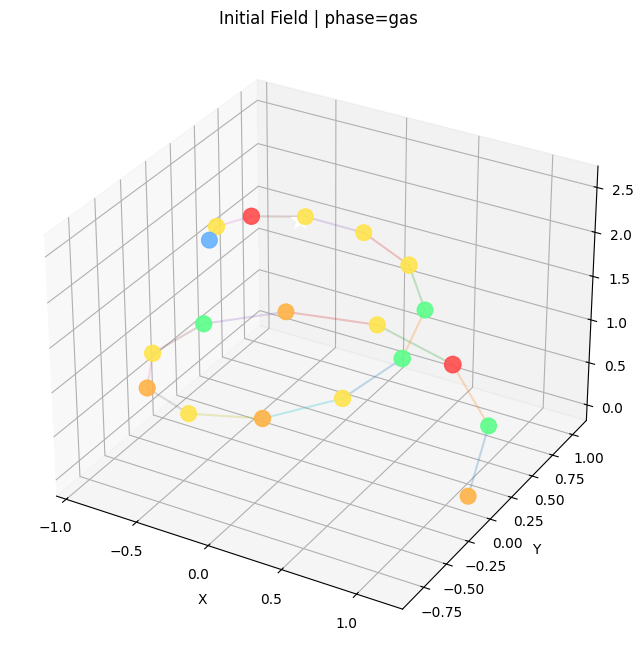

In [ ]:

field = init_bindu_field()
initial_metrics = compute_global_state(field)
initial_sieve = evaluate_sieve(initial_metrics)

print("=== INITIAL STATE ===")
print({
    "shadow": round(initial_metrics["shadow"], 3),
    "coherence": round(initial_metrics["coherence"], 3),
    "target_fit": round(initial_metrics["target_fit"], 3),
    "vitality": round(initial_metrics["vitality"], 3),
    "freq": round(initial_metrics["coherence_frequency"], 3),
    "interference": round(initial_metrics["interference"], 3),
    "phase": initial_metrics["phase"],
    "sieve_score": initial_sieve["sieve_score"],
    "sieve_passed": initial_sieve["passed"],
})

plot_bindu_field(field, title=f"Initial Field | phase={initial_metrics['phase']}")

In [ ]:

# =========================================================
# FULL EPISODE LOOP
# =========================================================

def run_bindu_cicada_episode(initial_field, max_steps=MAX_STEPS):
    current_field = copy.deepcopy(initial_field)
    memory = []
    trace = []
    bindu_hold = 0

    for step in range(max_steps):
        current_metrics = compute_global_state(current_field)
        mode = route_mode_from_metrics(current_metrics)

        coalition_results = evaluate_bindu_coalitions(current_field, mode)
        best_name, best_data = select_best_coalition(coalition_results)

        decision = gate_decision(best_data["metrics"], best_data["sieve"])

        trace.append({
            "step": step,
            "mode": mode,
            "coalition": best_name,
            "decision": decision,
            "phase": best_data["metrics"]["phase"],
            "shadow": round(best_data["metrics"]["shadow"], 3),
            "coherence": round(best_data["metrics"]["coherence"], 3),
            "target_fit": round(best_data["metrics"]["target_fit"], 3),
            "vitality": round(best_data["metrics"]["vitality"], 3),
            "freq": round(best_data["metrics"]["coherence_frequency"], 3),
            "interference": round(best_data["metrics"]["interference"], 3),
            "sieve_score": best_data["sieve"]["sieve_score"],
            "sieve_passed": best_data["sieve"]["passed"],
        })

        if decision in ["COMMIT", "SOFT_COMMIT"]:
            current_field = copy.deepcopy(best_data["field"])
            memory.append(trace[-1])

        elif decision == "REROUTE":
            fallback = reroute_mode(mode)
            fallback_results = evaluate_bindu_coalitions(current_field, fallback)
            rer_name, rer_data = select_best_coalition(fallback_results)

            rer_decision = gate_decision(rer_data["metrics"], rer_data["sieve"])

            trace.append({
                "step": step,
                "mode": fallback,
                "coalition": rer_name,
                "decision": f"FALLBACK_{rer_decision}",
                "phase": rer_data["metrics"]["phase"],
                "shadow": round(rer_data["metrics"]["shadow"], 3),
                "coherence": round(rer_data["metrics"]["coherence"], 3),
                "target_fit": round(rer_data["metrics"]["target_fit"], 3),
                "vitality": round(rer_data["metrics"]["vitality"], 3),
                "freq": round(rer_data["metrics"]["coherence_frequency"], 3),
                "interference": round(rer_data["metrics"]["interference"], 3),
                "sieve_score": rer_data["sieve"]["sieve_score"],
                "sieve_passed": rer_data["sieve"]["passed"],
            })

            if rer_decision in ["COMMIT", "SOFT_COMMIT"]:
                current_field = copy.deepcopy(rer_data["field"])
                memory.append(trace[-1])

        final_metrics = compute_global_state(current_field)
        if is_near_bindu_open(final_metrics):
            bindu_hold += 1
        else:
            bindu_hold = 0

        if bindu_hold >= BINDU_HOLD_CYCLES:
            return current_field, memory, trace, True

    return current_field, memory, trace, False


final_field, memory_log, episode_trace, bindu_opened = run_bindu_cicada_episode(field)

In [ ]:

print("=== BINDU + CICADA EPISODE TRACE ===\n")

for row in episode_trace:
    print(
        f"step={row['step']} | "
        f"mode={row['mode']:10s} | "
        f"coalition={row['coalition']:20s} | "
        f"decision={row['decision']:15s} | "
        f"phase={row['phase']:8s} | "
        f"shadow={row['shadow']:.3f} | "
        f"coh={row['coherence']:.3f} | "
        f"fit={row['target_fit']:.3f} | "
        f"vit={row['vitality']:.3f} | "
        f"freq={row['freq']:.3f} | "
        f"intf={row['interference']:.3f} | "
        f"sieve={row['sieve_score']:.3f} | "
        f"pass={row['sieve_passed']}"
    )

print("\n=== MEMORY LOG ===\n")
for row in memory_log:
    print(row)

final_metrics = compute_global_state(final_field)
final_sieve = evaluate_sieve(final_metrics)

print("\n=== FINAL FIELD ===")
print({
    "shadow": round(final_metrics["shadow"], 3),
    "coherence": round(final_metrics["coherence"], 3),
    "target_fit": round(final_metrics["target_fit"], 3),
    "vitality": round(final_metrics["vitality"], 3),
    "freq": round(final_metrics["coherence_frequency"], 3),
    "interference": round(final_metrics["interference"], 3),
    "phase": final_metrics["phase"],
    "sieve_score": final_sieve["sieve_score"],
    "sieve_passed": final_sieve["passed"],
    "bindu_opened": bindu_opened,
})

=== BINDU + CICADA EPISODE TRACE ===

step=0 | mode=stabilize  | coalition=planner+stabilizer   | decision=REROUTE         | phase=gas      | shadow=0.069 | coh=0.564 | fit=0.668 | vit=0.756 | freq=0.753 | intf=0.034 | sieve=0.711 | pass=True
step=0 | mode=plan       | coalition=planner+stabilizer   | decision=FALLBACK_REROUTE | phase=gas      | shadow=0.069 | coh=0.564 | fit=0.668 | vit=0.756 | freq=0.753 | intf=0.034 | sieve=0.711 | pass=True
step=1 | mode=stabilize  | coalition=planner+stabilizer   | decision=REROUTE         | phase=gas      | shadow=0.069 | coh=0.564 | fit=0.668 | vit=0.756 | freq=0.753 | intf=0.034 | sieve=0.711 | pass=True
step=1 | mode=plan       | coalition=planner+stabilizer   | decision=FALLBACK_REROUTE | phase=gas      | shadow=0.069 | coh=0.564 | fit=0.668 | vit=0.756 | freq=0.753 | intf=0.034 | sieve=0.711 | pass=True
step=2 | mode=stabilize  | coalition=planner+stabilizer   | decision=REROUTE         | phase=gas      | shadow=0.069 | coh=0.564 | fit=0.668

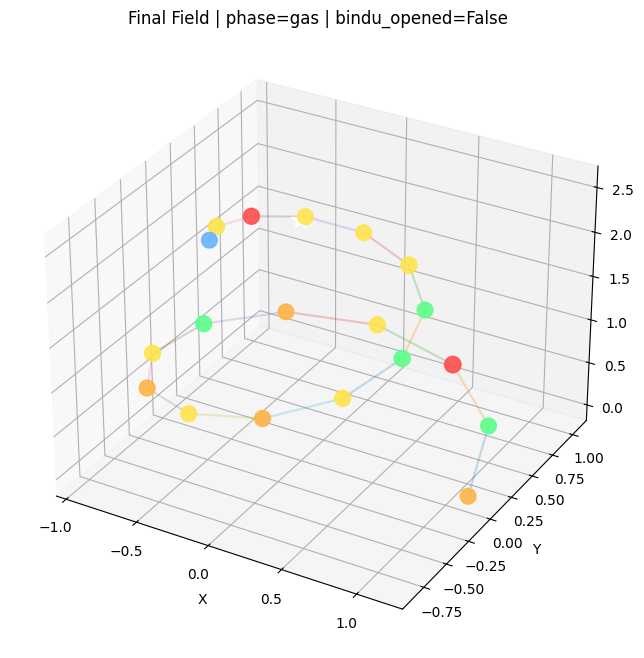

In [ ]:

plot_bindu_field(
    final_field,
    title=f"Final Field | phase={final_metrics['phase']} | bindu_opened={bindu_opened}"
)

In [ ]:

steps = list(range(len(memory_log)))
shadow_vals = [row["shadow"] for row in memory_log]
coh_vals = [row["coherence"] for row in memory_log]
fit_vals = [row["target_fit"] for row in memory_log]
vit_vals = [row["vitality"] for row in memory_log]
freq_vals = [row["freq"] for row in memory_log]
sieve_vals = [row["sieve_score"] for row in memory_log]

if len(steps) > 0:
    plt.figure(figsize=(11, 5))
    plt.plot(steps, shadow_vals, marker="o", label="shadow")
    plt.plot(steps, coh_vals, marker="o", label="coherence")
    plt.plot(steps, fit_vals, marker="o", label="target_fit")
    plt.plot(steps, vit_vals, marker="o", label="vitality")
    plt.plot(steps, freq_vals, marker="o", label="coherence_frequency")
    plt.plot(steps, sieve_vals, marker="o", label="sieve_score")
    plt.title("Bindu + Cicada Memory Metrics")
    plt.xlabel("memory step")
    plt.ylabel("value")
    plt.legend()
    plt.show()
else:
    print("No committed memory states recorded.")

No committed memory states recorded.
